# DRUHÁ PREDIKCE - Typ poruchy

In [211]:
import pandas as pd
import matplotlib.pyplot as plt

# Načtení datasetu
df = pd.read_csv("../data/ML/Predictive_Dataset.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp")
# Kontrola dat
df.head()

,timestamp,machine_id,temperature,vibration,pressure,load,ambient_temperature,is_running,produced_units,defective_units,...,rolling_vibration_std_24h,rolling_pressure_mean_24h,rolling_pressure_std_24h,running_ratio_24h,hours_since_last_failure,failure_count_last_7d,failure_count_last_30d,target_failure_72h,target_failure_type,target_RUL_hours
0,2022-01-01,1,49.3,2.28,4.61,89.27,17.8,1,120,2,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1617.0
78843,2022-01-01,4,49.3,2.28,4.61,89.27,17.8,1,73,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1296.0
105124,2022-01-01,5,49.3,2.28,4.61,89.27,17.8,1,120,2,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1818.0
131405,2022-01-01,6,49.3,2.28,4.61,89.27,17.8,1,97,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1110.0
26281,2022-01-01,2,49.3,2.28,4.61,89.27,17.8,1,97,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1242.0


In [212]:
# Výběr pouze záznamů, kde je porucha do 72h
df_type = df[df["target_failure_72h"] == 1].copy()

df_type["hours_since_last_failure"] = df_type["hours_since_last_failure"].fillna(df_type["machine_age_hours"])

features = df_type.columns.drop([
    "timestamp",
    "machine_id",
    "target_failure_72h",
    "target_failure_type",
    "target_RUL_hours",
    "health_index",
    "produced_units",
    "defective_units",
]).tolist()

df_type.shape

(31248, 27)

In [213]:
df_type = df_type.dropna(subset=features)
df_type = df_type.reset_index(drop=True)

df_type.isnull().sum()

timestamp                            0
machine_id                           0
temperature                          0
vibration                            0
pressure                             0
load                                 0
ambient_temperature                  0
is_running                           0
produced_units                       0
defective_units                      0
operating_hours_since_maintenance    0
machine_age_hours                    0
health_index                         0
health_delta_24h                     0
rolling_temp_mean_24h                0
rolling_temp_std_24h                 0
rolling_vibration_mean_24h           0
rolling_vibration_std_24h            0
rolling_pressure_mean_24h            0
rolling_pressure_std_24h             0
running_ratio_24h                    0
hours_since_last_failure             0
failure_count_last_7d                0
failure_count_last_30d               0
target_failure_72h                   0
target_failure_type      

In [214]:
df_type.shape

(31248, 27)

In [215]:
# Počet záznamů poruch dle typu
df_type["target_failure_type"].value_counts()

target_failure_type
mechanical     9360
overheating    8424
pressure       7632
electrical     5832
Name: count, dtype: int64

In [216]:
# Rozdělení dat dle času (model se učí na starých datech a testuje na nových)
# Seřazení dat
df_type = df_type.sort_values("timestamp")

split_time = df_type["timestamp"].quantile(0.8)

# Split podle času
train = df_type[df_type["timestamp"] < split_time]
test = df_type[df_type["timestamp"] >= split_time]

# Vytvoření X a y
X_train = train[features]
y_train = train["target_failure_type"]

X_test = test[features]
y_test = test["target_failure_type"]

In [217]:
# Logistická regrese
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lr = LogisticRegression(max_iter=2000)
model_lr.fit(X_train_scaled, y_train)

pred_lr = model_lr.predict(X_test_scaled)

In [218]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

In [219]:
# Gradient Boosting
from sklearn.ensemble import HistGradientBoostingClassifier

model_gb = HistGradientBoostingClassifier(max_depth=5, random_state=42)

model_gb.fit(X_train, y_train)

pred_gb = model_gb.predict(X_test)

In [220]:
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, pred_lr))

print("\n=== Random Forest ===")
print(classification_report(y_test, pred_rf))

print("\n=== Gradient Boosting ===")
print(classification_report(y_test, pred_gb))

=== Logistic Regression ===
              precision    recall  f1-score   support

  electrical       0.41      0.76      0.53      1224
  mechanical       0.36      0.39      0.37      1872
 overheating       0.28      0.31      0.29      1427
    pressure       0.41      0.09      0.14      1728

    accuracy                           0.36      6251
   macro avg       0.36      0.39      0.34      6251
weighted avg       0.36      0.36      0.32      6251


=== Random Forest ===
              precision    recall  f1-score   support

  electrical       0.30      0.26      0.28      1224
  mechanical       0.39      0.39      0.39      1872
 overheating       0.31      0.41      0.35      1427
    pressure       0.52      0.41      0.46      1728

    accuracy                           0.38      6251
   macro avg       0.38      0.37      0.37      6251
weighted avg       0.39      0.38      0.38      6251


=== Gradient Boosting ===
              precision    recall  f1-score   suppor

In [221]:
#  Test zlepšení Gradient Boosting
from sklearn.ensemble import HistGradientBoostingClassifier

model_gb_tuned = HistGradientBoostingClassifier(
    max_depth=12,
    learning_rate=0.05,
    max_iter=200,
    random_state=42
)

model_gb_tuned.fit(X_train, y_train)
pred_gb_tuned = model_gb_tuned.predict(X_test)

In [222]:
from sklearn.metrics import classification_report

print("=== Gradient Boosting ===")
print(classification_report(y_test, pred_gb))

print("\n=== Gradient Boosting Tuned ===")
print(classification_report(y_test, pred_gb_tuned))

=== Gradient Boosting ===
              precision    recall  f1-score   support

  electrical       0.36      0.46      0.40      1224
  mechanical       0.41      0.35      0.38      1872
 overheating       0.43      0.62      0.51      1427
    pressure       0.51      0.30      0.38      1728

    accuracy                           0.42      6251
   macro avg       0.43      0.43      0.42      6251
weighted avg       0.43      0.42      0.41      6251


=== Gradient Boosting Tuned ===
              precision    recall  f1-score   support

  electrical       0.33      0.43      0.37      1224
  mechanical       0.44      0.38      0.41      1872
 overheating       0.36      0.52      0.42      1427
    pressure       0.63      0.35      0.45      1728

    accuracy                           0.41      6251
   macro avg       0.44      0.42      0.41      6251
weighted avg       0.45      0.41      0.42      6251



In [223]:
print(len(features))
print(features)

19
['temperature', 'vibration', 'pressure', 'load', 'ambient_temperature', 'is_running', 'operating_hours_since_maintenance', 'machine_age_hours', 'health_delta_24h', 'rolling_temp_mean_24h', 'rolling_temp_std_24h', 'rolling_vibration_mean_24h', 'rolling_vibration_std_24h', 'rolling_pressure_mean_24h', 'rolling_pressure_std_24h', 'running_ratio_24h', 'hours_since_last_failure', 'failure_count_last_7d', 'failure_count_last_30d']


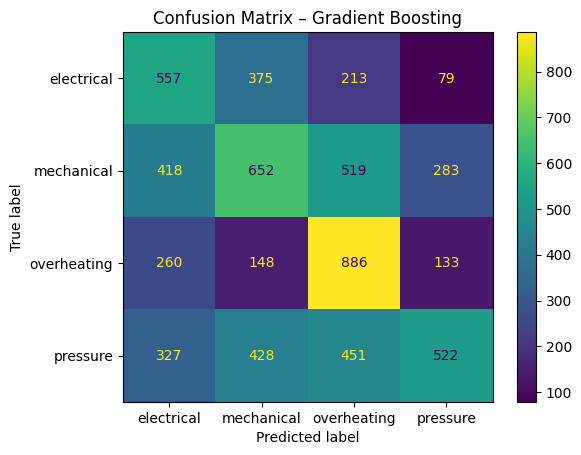

In [224]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, pred_gb)

plt.title("Confusion Matrix – Gradient Boosting")
plt.show()

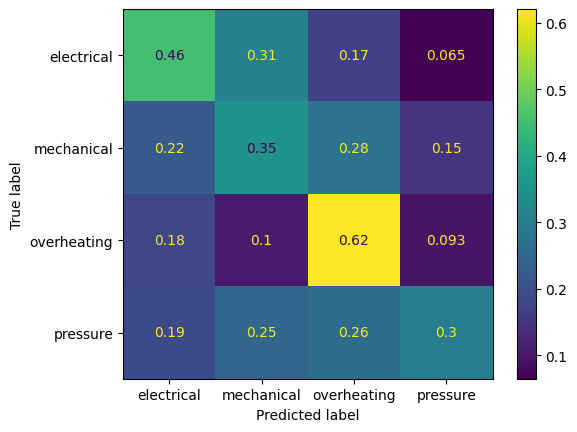

In [225]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_gb,
    normalize="true"
)

In [226]:
from sklearn.metrics import balanced_accuracy_score

balanced_accuracy_score(y_test, pred_gb)

0.43158056559236274

In [227]:
import pandas as pd

importances = model_rf.feature_importances_

feat_importance = pd.Series(importances, index=features).sort_values(ascending=False)

feat_importance.head(10)

machine_age_hours                    0.258607
hours_since_last_failure             0.134864
operating_hours_since_maintenance    0.127303
rolling_temp_mean_24h                0.111534
health_delta_24h                     0.100166
rolling_vibration_mean_24h           0.066918
ambient_temperature                  0.049322
rolling_pressure_mean_24h            0.042178
rolling_temp_std_24h                 0.024375
rolling_vibration_std_24h            0.024234
dtype: float64

In [228]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report

# definice "časových" features
time_features = [
    "machine_age_hours",
    "hours_since_last_failure",
    "operating_hours_since_maintenance"
]

# nové features BEZ těchto sloupců
features_no_time = [f for f in features if f not in time_features]

# vytvoření datasetu
X_train_no_time = train[features_no_time]
X_test_no_time = test[features_no_time]

y_train = train["target_failure_type"]
y_test = test["target_failure_type"]

# model (stejný jako hlavní!)
model_gb_no_time = HistGradientBoostingClassifier(random_state=42)

model_gb_no_time.fit(X_train_no_time, y_train)

pred_gb_no_time = model_gb_no_time.predict(X_test_no_time)

# výstupy
print("=== Gradient Boosting (FULL FEATURES) ===")
print(classification_report(y_test, pred_gb))

print("\n=== Gradient Boosting (WITHOUT TIME FEATURES) ===")
print(classification_report(y_test, pred_gb_no_time))

=== Gradient Boosting (FULL FEATURES) ===
              precision    recall  f1-score   support

  electrical       0.36      0.46      0.40      1224
  mechanical       0.41      0.35      0.38      1872
 overheating       0.43      0.62      0.51      1427
    pressure       0.51      0.30      0.38      1728

    accuracy                           0.42      6251
   macro avg       0.43      0.43      0.42      6251
weighted avg       0.43      0.42      0.41      6251


=== Gradient Boosting (WITHOUT TIME FEATURES) ===
              precision    recall  f1-score   support

  electrical       0.30      0.26      0.28      1224
  mechanical       0.34      0.37      0.35      1872
 overheating       0.29      0.36      0.32      1427
    pressure       0.25      0.19      0.21      1728

    accuracy                           0.30      6251
   macro avg       0.29      0.30      0.29      6251
weighted avg       0.29      0.30      0.29      6251



# ZOBRAZIT VÝSLEDKY MODELU